In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

In [2]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Normalize the images (between 0 and 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.


In [4]:
# Add random noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)


In [5]:
# Clip the images to be between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [6]:
# Build the autoencoder model
input_img = Input(shape=(28, 28))
x = Flatten()(input_img)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(28*28, activation='sigmoid')(x)
output = Reshape((28, 28))(x)

autoencoder = Model(input_img, output)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

In [7]:
# Train the model
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.2784 - val_loss: 0.1586
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1536 - val_loss: 0.1398
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1389 - val_loss: 0.1323
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1323 - val_loss: 0.1277
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1274 - val_loss: 0.1248
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1240 - val_loss: 0.1212
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.1213 - val_loss: 0.1197
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.1198 - val_loss: 0.1180
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1181 - val_loss: 0.1174
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1170 - val_loss: 0.1160


In [8]:
# Predict on the noisy test images
decoded_imgs = autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


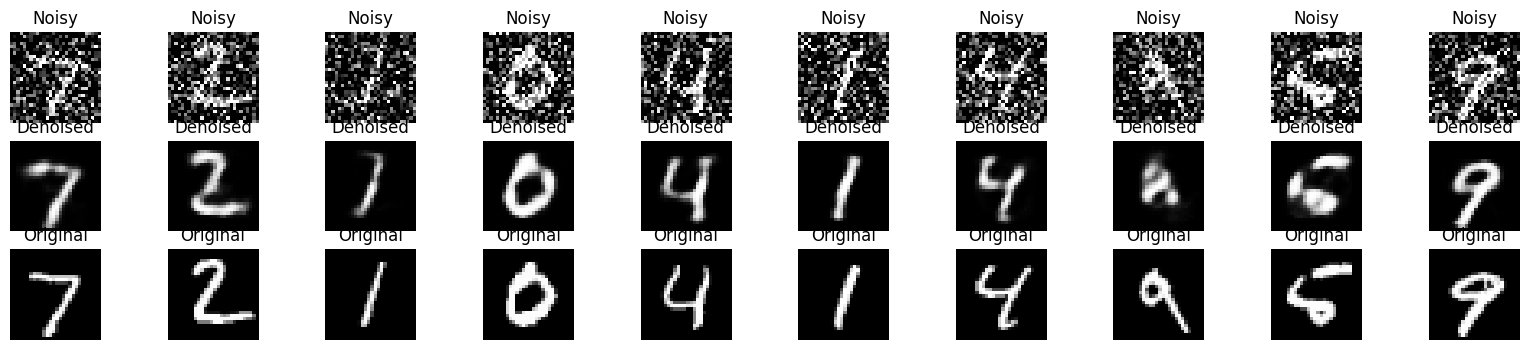

In [13]:
 n = 10  # number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # display reconstructed (denoised)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # display original
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')
plt.show()
